# AttritionIQ - EDA (Phase 1)

Data: IBM HR Analytics Employee Attrition (1,470 employees; a fictional dataset created by IBM data scientists).

In [1]:
import sys; sys.path.append("..")
import pandas as pd, matplotlib.pyplot as plt
from src import config
from src.data import load_raw, clean, quality_report
raw = load_raw(); df = clean(raw)

In [2]:
quality_report(raw)

{'rows': 1470,
 'duplicate_employee_ids': 0,
 'missing_values': 0,
 'constant_columns': ['EmployeeCount', 'Over18', 'StandardHours'],
 'years_at_company_gt_total': 0,
 'years_in_role_gt_company': 0,
 'years_with_manager_gt_company': 0,
 'promotion_gt_company': 0}

**Data quality.** 0 duplicate employee IDs, 0 missing values, 0 impossible tenure values (e.g. years in role > years at company). The only problems are 3 constant columns (`EmployeeCount`, `Over18`, `StandardHours`), which carry no information and are dropped via `config.DROP_COLS`.

In [3]:
df[config.TARGET].value_counts(normalize=True)

Attrition
0    0.838776
1    0.161224
Name: proportion, dtype: float64

#### Predicting "nobody leaves" already scores about 84% accuracy, which is why the project uses PR-AUC instead

In [4]:
left = raw["Attrition"].eq("Yes")
for col in ["OverTime", "JobRole", "JobLevel", "MaritalStatus", "BusinessTravel", "Department"]:
    print(left.groupby(raw[col]).mean().sort_values(ascending=False).round(3), "\n")

OverTime
Yes    0.305
No     0.104
Name: Attrition, dtype: float64 

JobRole
Sales Representative         0.398
Laboratory Technician        0.239
Human Resources              0.231
Sales Executive              0.175
Research Scientist           0.161
Manufacturing Director       0.069
Healthcare Representative    0.069
Manager                      0.049
Research Director            0.025
Name: Attrition, dtype: float64 

JobLevel
1    0.263
3    0.147
2    0.097
5    0.072
4    0.047
Name: Attrition, dtype: float64 

MaritalStatus
Single      0.255
Married     0.125
Divorced    0.101
Name: Attrition, dtype: float64 

BusinessTravel
Travel_Frequently    0.249
Travel_Rarely        0.150
Non-Travel           0.080
Name: Attrition, dtype: float64 

Department
Sales                     0.206
Human Resources           0.190
Research & Development    0.138
Name: Attrition, dtype: float64 



**Who leaves.** Overtime workers leave at 30.5% vs 10.4%. Sales Representatives (39.8%), entry level (JobLevel 1: 26.3%), single employees (25.5%) and frequent travellers (24.9%) are the high-risk groups. The overall rate is 16.1% (237 of 1,470).

Caution: these are associations, not causes. Several overlap (most sales reps are entry level), which is why the model, not single-feature tables, makes the prediction.

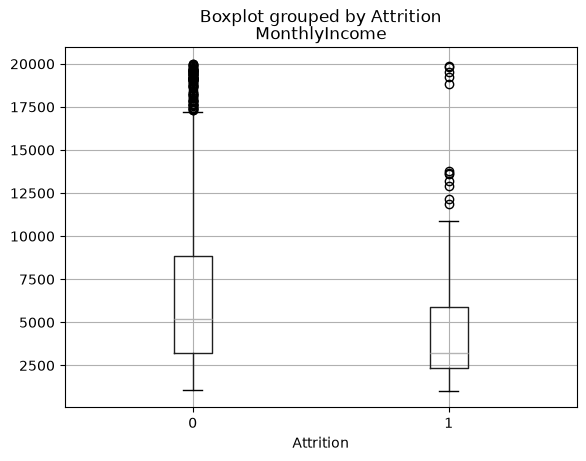

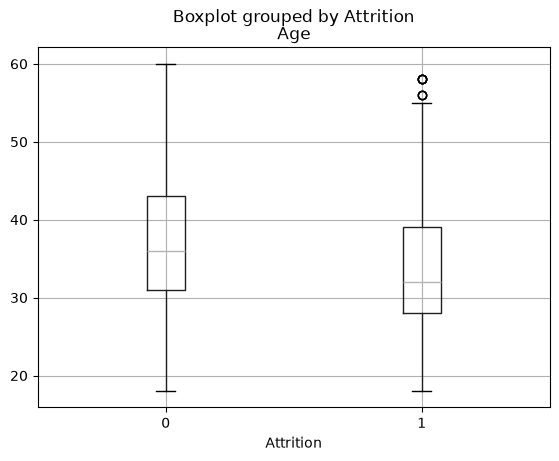

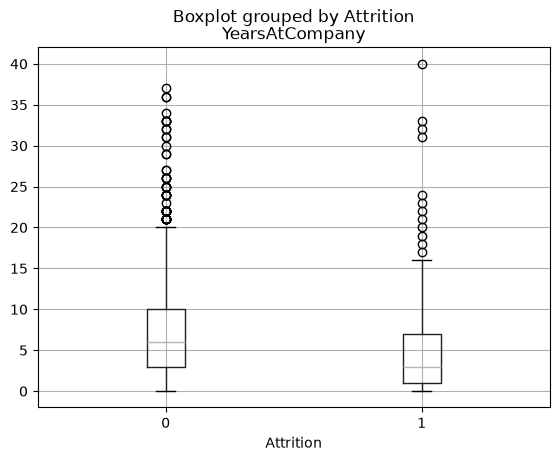

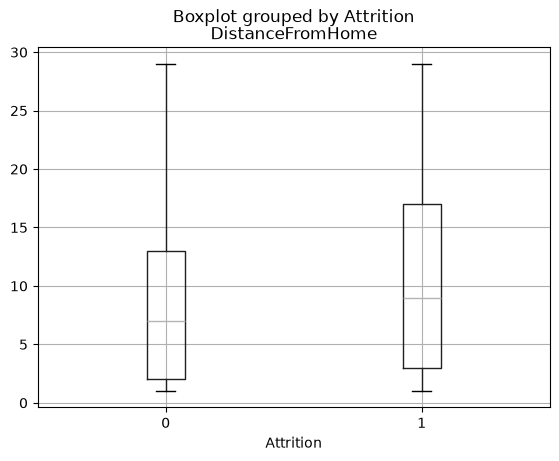

In [5]:
for c in ["MonthlyIncome", "Age", "YearsAtCompany", "DistanceFromHome"]:
    df.boxplot(column=c, by=config.TARGET); plt.show()

**Distributions.** Leavers earn less (median 3,202 vs 5,204 per month, dataset units), are younger (32 vs 36), have shorter tenure (3 vs 6 years) and live slightly further away (9 vs 7). Income and tenure are right-skewed, one reason the pipeline scales features.

In [6]:
corr = df.select_dtypes("number").corr()
pairs = corr.where(lambda m: m.abs() > 0.7).stack().dropna()
pairs[pairs.index.get_level_values(0) < pairs.index.get_level_values(1)].sort_values()

YearsInCurrentRole  YearsWithCurrManager    0.714365
YearsAtCompany      YearsInCurrentRole      0.758754
                    YearsWithCurrManager    0.769212
MonthlyIncome       TotalWorkingYears       0.772893
PercentSalaryHike   PerformanceRating       0.773550
JobLevel            TotalWorkingYears       0.782208
                    MonthlyIncome           0.950300
dtype: float64

**Correlated pairs (|r| > 0.7).** JobLevel and MonthlyIncome are near-duplicates (r = 0.95); the tenure variables move together (0.71-0.78). Consequence: logistic-regression coefficients and SHAP values for these pairs share credit, so we explain them as a group, not one by one.

## Phase 1 decisions

**Engineered features** (`experiments/feature_ablation.py`, results in `reports/feature_ablation.json`). Each candidate was removed one at a time and scored on the same 15 CV folds (5-fold x 3 repeats, train split only) with Logistic Regression and an untuned XGBoost. The rule was fixed before looking at results: keep a feature only if removing it lowers PR-AUC in **both** models **and** the Nadeau-Bengio corrected t-test gives p < 0.10 in at least one.

| Feature | LR gain from keeping | XGB gain from keeping | Decision |
|---|---|---|---|
| YearsPerCompany | -0.003 | 0.000 | Drop |
| PromotionLagRatio | -0.003 | -0.002 | Drop |
| ManagerTenureRatio | +0.010 (p = 0.15) | +0.002 | Drop (closest call) |
| SatisfactionIndex | 0.000 | +0.002 | Drop |

SatisfactionIndex is the average of four columns already in the model, so a linear model can rebuild it exactly; zero gain is expected. XGBoost's scores moved by about 0.01 just from reordering columns, so gains of that size are noise. All four features are still computed for the recommender and error analysis; they are just not model inputs (`MODEL_ENGINEERED = []` in `src/data.py`).

**Sensitive features** (Gender, Age, MaritalStatus). Including them adds about +0.016 PR-AUC (LR, p = 0.16; XGB +0.017, p = 0.30), smaller than the fold-to-fold spread (± 0.06). Decision: keep them **excluded** (`EXCLUDE_SENSITIVE = True`). The model gives up very little and does not base retention decisions on protected attributes. Excluding them does not make the model fair by itself: Age correlates with tenure and income, so the Phase 2 fairness report still checks gaps by age band and gender.